# K近邻(KNN)图像分类底层完整实现
## 项目概述
从零实现KNN图像分类完整链路，基于CIFAR-10数据集对比三种距离计算方案，从低效多层循环到纯向量化矩阵运算，验证算法效率差异；通过交叉验证遍历超参K，筛选最优分类配置，完整复现传统图像分类全流程。

## KNN算法核心逻辑拆解
1. 训练阶段：无参数训练，仅存储全部训练样本特征；
2. 推理阶段：计算测试样本与全量训练样本欧式距离，选取距离最近K个样本投票得到分类结果；
3. 超参优化：采用交叉验证遍历候选K值，基于验证集准确率选取最优超参。

## 实验内容
1. 图像数据集预处理：样本降采样、特征展平、可视化样本分布；
2. 三种距离计算实现：双层循环、单层循环、纯向量化矩阵运算，对比计算性能；
3. 超参搜索：遍历多组K值，统计对应分类准确率；
4. 交叉验证筛选最优K，使用最优配置完成测试集最终效果验证。

## 学习收获
深入理解numpy广播、矩阵运算优化思路，掌握传统机器学习算法从底层实现、实验调参到效果验证的完整工程流程。

In [4]:
# 启动配置（import / 魔法命令 / 绘图参数）

import random
import numpy as np
from datasets.data_utils import load_CIFAR10  #CIFAR10 是机器学习入门最经典的10分类彩色图片数据集，包含5万张训练图、1万张测试图，每张图是32×32像素，分为飞机、汽车、猫、狗等10个类别
import matplotlib.pyplot as plt  #导入矩阵绘图库
from pylab import mpl            #导入mpl模块用于配置 matplotlib 的全局参数，这里设置默认字体为黑体，解决 matplotlib 绘图时中文显示乱码的问题
mpl.rcParams['font.sans-serif'] = ['SimHei']
from __future__ import print_function  # Python2和Python3的兼容语句，让Python2环境可以使用Python3的print()函数语法，保证代码在不同Python版本中都能正常运行

# 以%开头的命令，是Jupyter Notebook/IPython 专属的「魔法命令」，在纯 Python 脚本中无法使用
# %语法糖是Jupyter里的「行魔法命令」 是 get_ipython().run_line_magic() 的简写    (Jupyter的魔法命令有严格的语法要求：命令后只能跟模块名，不能附带行内注释)
# 让 matplotlib 绘制的所有图表，直接嵌入在 Notebook 的单元格内显示，而不是弹出独立的窗口，方便在 Notebook 中边写代码边看结果
%matplotlib inline
# 全局配置 matplotlib 的绘图默认参数
plt.rcParams['figure.figsize'] = (10.0, 8.0)    # 设置默认画布的尺寸为宽 10 英寸、高 8 英寸，让绘制的图片/图表更大更清晰
plt.rcParams['image.interpolation'] = 'nearest' # 设置图片插值方式为「最近邻插值」，显示图片时不会做平滑模糊处理，完美保留 CIFAR10 这种小像素图片的原始像素感
plt.rcParams['image.cmap'] = 'gray'             # image.cmap：设置图片的默认颜色映射为灰度模式，后续显示图片默认以灰度图呈现，也可以手动修改为彩色模式

# 自动加载模型
# 这个插件的核心作用是：当修改了外部导入的.py文件（比如后续写的kNN分类器代码），不需要重启Notebook的内核，重新运行单元格就会自动加载最新修改后的代码，极大提升开发调试效率
%load_ext autoreload
# %autoreload 2是最高级的重载模式，会在执行任何代码前，自动重载所有改动过的用户自定义模块
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [60]:
# 加载数据
# 定义 CIFAR-10 数据集的存放路径（相对路径）
cifar10_dir = '../datasets/cifar-10-batches-py'
# 清除变量，防止多次加载数据 (CIFAR-10 原始数据约150MB，多次加载会导致内存占用翻倍甚至卡顿，这是 Notebook 中加载大数据的 “防御性写法”)
try:
   del X_train, y_train
   del X_test, y_test
   print('清除先前加载的数据')
except:  # except：如果变量不存在（比如第一次运行），会触发异常，pass 表示 “忽略异常，不做任何操作”
   pass

# 调用自定义函数加载 CIFAR-10 数据
X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)
# 打印训练、测试数据的现状，看看是否合理
print('训练数据 shape: ', X_train.shape)
print('训练标签 shape: ', y_train.shape)
print('测试数据 shape: ', X_test.shape)
print('测试标签 shape: ', y_test.shape)

清除先前加载的数据
训练数据 shape:  (50000, 32, 32, 3)
训练标签 shape:  (50000,)
测试数据 shape:  (10000, 32, 32, 3)
测试标签 shape:  (10000,)


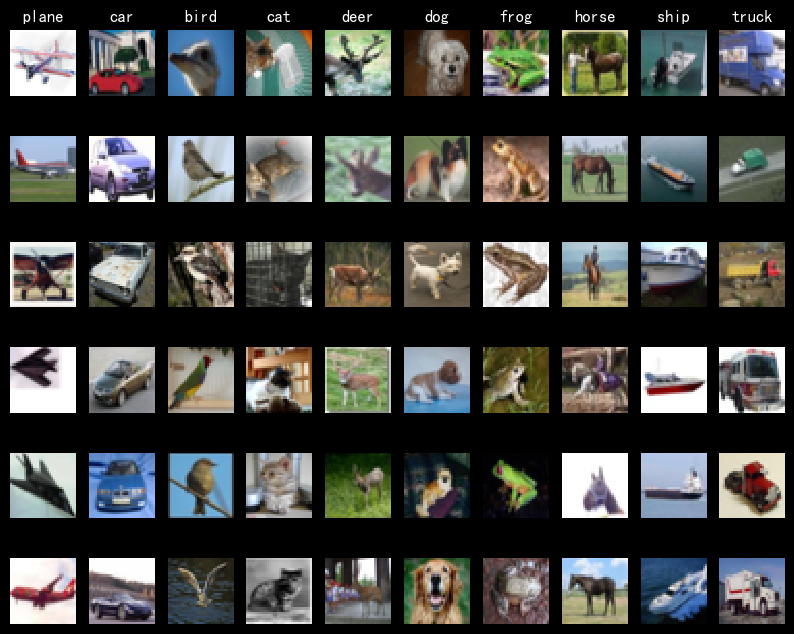

In [8]:
# 可视化部分样本数据，每个分类显示一小部分图片
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)  # 类别总数:10      (列数)
samples_per_class = 7       # 每个类别展示7张图  (行数)
'''
np.flatnonzero() 是 NumPy 中专门用来找数组里非零元素'位置'的函数
np.flatnonzero(y_train == y):  1.y_train == y → 生成布尔数组（True/False）;  2.flatnonzero → 找出所有 True 的位置

plt_idx = i * num_classes + y + 1   → 计算子图位置
总布局: 7行（每个类别7张图）× 10列（10个类别）
第i行、第y列的子图编号是 i*10 + y + 1 （子图编号从1开始）
i * num_classes: 先算 “前面已经占了多少个座位”。比如 i=1，前面已经有 1 行（10个座位），所以从第11个座位开始
+ y: 在当前行里，再往右数 y 个位置，找到对应类别的列
+ 1: 把从 0 开始的索引，转换成从 1 开始的座位号
这样，每个类别（y）的每张图（i），都能精准定位到网格里的唯一位置，形成整齐的 7×10 布局

plt.subplot(...): 创建对应位置的子图
plt.imshow(...):  显示图片。astype('uint8') 是关键：原始像素值是 float，转成 uint8（0~255）才能正常显示
plt.axis('off'):  关闭坐标轴，让图片更干净
if i == 0:        每个类别第一张图的子图，加上类别名作为标题
plt.imshow()： 把图片 “画到画布的子图位置上”（往格子里贴图片）
plt.show()：   把所有画好的内容（整个画布）“展示出来”（最终呈现）
'''
for y, cls in enumerate(classes):   # y：0~9;  cls：类别名
    idxs = np.flatnonzero(y_train == y)  # flatnonzero(条件) = 找出满足条件的所有元素的索引
    idxs = np.random.choice(idxs, samples_per_class, replace=False) # 从这些索引中随机选7个,不重复
    for i, idx in enumerate(idxs):  # i：0~6;  idx：该图在训练集中的索引
        plt_idx = i * num_classes + y + 1  # 计算子图位置(座位号)
        plt.subplot(samples_per_class, num_classes, plt_idx)  # 行数, 列数, 座位号(从1开始数)
        plt.imshow(X_train[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls)
plt.show()  # 把所有子图渲染出来，形成一个 7×10 的网格，每个类别一行，直观展示各类样本

In [11]:
# 拆分数据，方便更高效执行代码
# 原始训练集有50000张图，测试集有10000张图，kNN计算距离很慢，所以先取一小部分来跑

num_training = 5000  # 取前5000个样本作为训练集（减少计算量）
mask = list(range(num_training))  # 生成索引列表 [0, 1, 2, ..., 4999]，用于“筛选”前5000个样本
X_train = X_train[mask]
y_train = y_train[mask]

num_test = 500
mask = list(range(num_test))
X_test = X_test[mask]
y_test = y_test[mask]

In [23]:
# 将图片转换为行向量（展平）
# 原始图片形状是 (样本数, 32, 32, 3)，kNN需要每个样本是一维向量，方便计算距离

# 把每张 32×32×3 的图片展平成一维向量（32*32*3 = 3072）
'''
X_train = np.reshape(X_train, (X_train.shape[0], -1))   等于  X_train = X_train.reshape(X_train.shape[0], -1)
( X_train:要被重塑的原始数组,   （X_train.shape[0], -1）:目标形状的维度 )
作用: 将4维图片数据重塑为2维特征矩阵，适配kNN距离计算
1. X_train.shape[0] → 固定为5000（保持样本数量不变，每张图占一行）
2. -1 → 让NumPy自动算列数：总像素数32×32×3=3072（把每张图的所有像素摊平成一行）
3. 最终形状：(5000, 3072) → 5000行（对应5000张图），3072列（对应每张图的所有像素）
'''
#X_train = X_train.reshape(X_train.shape[0], -1)  # 完全等价
X_train = np.reshape(X_train, (X_train.shape[0], -1))  # 形状从 (5000, 32, 32, 3) → (5000, 3072)
X_test = np.reshape(X_test, (X_test.shape[0], -1))     # 形状从 (500, 32, 32, 3)  → (500, 3072)
print(f'X_train.shape:{X_train.shape},  X_test.shape:{X_test.shape}')

X_train.shape:(5000, 3072),  X_test.shape:(500, 3072)


In [34]:
from classifiers import KNearestNeighbor
# 创建一个 kNN 分类器对象
classifier = KNearestNeighbor()
# 训练一个 kNN 分类器是一个空操作: 简单记住训练数据即可，没有别的处理
classifier.train(X_train, y_train)

KNN 推理流程分为两步：
1. 计算测试样本与全量训练样本的距离矩阵；
2. 基于最近邻 k 个样本投票得到分类结果。

从计算训练样本与测试样本之间的距离矩阵开始。比如，如果有**Ntr**个训练样本，**Nte**个测试样本，则结果就是一个**Nte x Ntr**的矩阵，其中第(i,j)个元素就是第i个测试样本与第j个训练样本的距离。

双循环版本距离计算：逐样本遍历实现欧式距离计算，作为基础性能基准。

In [35]:
# 打开 classifiers/k_nearest_neighbor.py 编码实现的 compute_distances_two_loops 方法
print("开始计算距离...")
# 测试代码
dists = classifier.compute_distances_two_loops(X_test)
'''
对于真实的 3072 像素：
  先找到第 i 张测试图的 3072 个像素值：[p1, p2, p3, ..., p3072]
  再找到第 j 张训练图的 3072 个像素值：[q1, q2, q3, ..., q3072]
  逐像素计算差值平方：(p1-q1)² + (p2-q2)² + ... + (p3072-q3072)²
  最后开平方，得到的结果就是 dists[i,j]
'''
print(dists.shape)

开始计算距离...
(500, 5000)


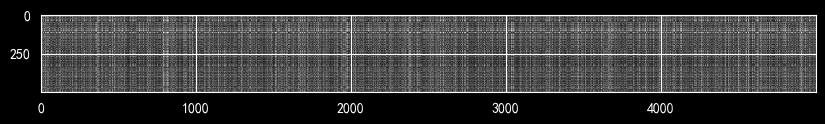

In [47]:
# 可视化距离矩阵: 每行是一个测试样本与所有训练样本的距离
'''
整张图：是 500 个测试图 vs 5000 个训练图的 “相似度对照表”
图的本质是 “每个 dists[i,j] 对应一个颜色点”
亮行：这个测试图 “谁都不像” (此测试样本和所有训练样本距离都大)
亮列：这个训练图 “谁都不像” (此训练样本和所有测试样本距离都大)
'''
plt.imshow(dists, interpolation='none')
plt.show()

实验观察：距离矩阵特征分析
- 对距离矩阵可视化后可观察到局部亮行、亮列现象，本质对应样本间相似度分布特征：
- 亮行：对应单个测试样本与所有训练样本距离均偏大，说明该测试样本特征在训练集中无相似同类，属于离群样本；
- 亮列：对应单个训练样本与所有测试样本距离均偏大，说明该训练样本特征特殊，在测试集中无同类匹配。

In [48]:
# 编码实现了 predict_labels 方法，运行一下代码
# k = 1 时
y_test_pred = classifier.predict_labels(dists, k=1)
# 计算和打印正确预测样本的比率
# 正确预测数量
num_correct = np.sum(y_test_pred == y_test)
# 准确率
accuracy = float(num_correct) / num_test
print('有 %d / %d 正确 => 准确率: %f' % (num_correct, num_test, accuracy))

有 137 / 500 正确 => 准确率: 0.274000


	k=1 时测试准确率约 27%；进一步测试 k=5 配置，对比分类效果差异。

In [49]:
y_test_pred = classifier.predict_labels(dists, k=5)
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print('有 %d / %d 正确 => 准确率: %f' % (num_correct, num_test, accuracy))

有 139 / 500 正确 => 准确率: 0.278000


实验验证 k=5 相比 k=1 分类效果有小幅提升。

拓展分析：不同距离度量的鲁棒性
- 对比 L1 与 L2 距离对数据预处理的敏感度：
- L1 距离具备平移不变性，均值消减操作不会改变样本间相对距离，因此不会提升分类性能；而数据缩放、坐标轴旋转会改变距离分布，可能影响分类效果。

In [50]:
# 单循环向量化优化：保留外层循环，内层通过 numpy 向量化批量计算，对比基础双循环版本性能。
# 编码实现了方法 compute_distances_one_loop 然后运行一下代码
dists_one = classifier.compute_distances_one_loop(X_test)

# 为了确保向量计算的正确性，将向量计算结果与普通计算结果比较。
# 比较两个矩阵是否相似的方法有很多，其中一个简单的是Frobenius范数
# 两个矩阵的Frobenius范数是所有元素的差异的平方和的平方根；实际就是，将矩阵转换为向量，然后计算它们之间的欧氏距离。
'''
Frobenius 范数（弗罗贝尼乌斯范数）= 矩阵的 “整体差异值”: 可理解成矩阵版的欧式距离
核心定义
对两个形状相同的矩阵 A 和 B：
1.先把 A 和 B 对应位置的元素相减，得到一个 “差异矩阵”；
2.把差异矩阵里所有元素都平方；
3.把这些平方值全部加起来；
4.最后开平方根。
这个最终结果就是 A 和 B 之间的 Frobenius 范数，用来衡量两个矩阵的 “整体差异大小”。
'''
difference = np.linalg.norm(dists - dists_one, ord='fro')
'''
linalg:     linear algebra（线性代数）的缩写，专门处理 矩阵/向量 的线性代数操作
norm:       “范数” 的英文，核心作用是计算 “矩阵/向量 的 大小/差异”
ord='fro':  指定计算 Frobenius 范数（可以简写为 ord='f'），这是针对矩阵的范数类型，专门衡量两个矩阵的整体差异
'''
print(f'差异是: {difference:.6f}')
if difference < 0.001:
    print('很好，距离是一样的')
else:
    print('哦啊，还有差距')

差异是: 0.000000
很好，距离是一样的


In [51]:
# 纯向量化无循环实现：基于 L2 距离展开公式，通过矩阵乘法 + 广播完成全量距离计算，最大化计算效率。
dists_two = classifier.compute_distances_no_loops(X_test)
# 比较差异
difference = np.linalg.norm(dists - dists_two, ord='fro')
print('差异是: %f' % (difference, ))
if difference < 0.001:
    print('很好，距离是一样的')
else:
    print('哦啊，还有差距')

差异是: 0.000000
很好，距离是一样的


In [52]:
# 比较一下三个方法的运算速度
def time_function(f, *args):
    '''
    计算调用一个方法的执行时间
    :param f:    要计时的函数 （比如 classifier.compute_distances_two_loops）
    :param args: 要传给 f 的所有参数 （比如 X_test）
    :return:     时间差
    '''
    import time       # 导入 time 模块，获取当前时间
    tic = time.time() # 记录开始时间（当前时间戳，单位：秒）
    f(*args)          # 执行要计时的函数 f，并传入所有参数 *args
    toc = time.time() # 记录结束时间
    return toc - tic  # 返回执行耗时：结束时间 - 开始时间

two_loop_time = time_function(classifier.compute_distances_two_loops, X_test)
print('两个循环的方法用时 %f 秒' % two_loop_time)

one_loop_time = time_function(classifier.compute_distances_one_loop, X_test)
print('一个循环的方法用时 %f 秒' % one_loop_time)

no_loop_time = time_function(classifier.compute_distances_no_loops, X_test)
print('没有循环的方法用时 %f 秒' % no_loop_time)

# 可以看到完全用向量的方法计算的速度快很多

两个循环的方法用时 11.130463 秒
一个循环的方法用时 39.610456 秒
没有循环的方法用时 0.112317 秒


### 交叉验证
已经写好了一个k最近邻分类器，但是k被武断地设置为5。下面要用交叉验证的方法找出这个超参数k最好的取值。

In [53]:
'''
5折交叉验证超参寻优设计：
1. 将训练集均分为5份子集；
2. 遍历所有候选k值，每组k执行5轮验证：轮流以1份子集为验证集、剩余4份为训练集，记录每轮准确率；
3. 统计每组k的平均准确率，筛选最优超参。
'''
# 做5个折叠的交叉验证
num_folds = 5
# 尝试以下k值
k_choices = [1, 3, 5, 8, 10, 12, 15, 20, 50, 100]
X_train_folds = []
y_train_folds = []
# 将训练数据拆分
# np.array_split(数组, 份数)：默认按行拆分成指定份数（平均分）
# 把 X_train 和 y_train 都分成 num_folds 份
# 把 X_train（形状(5000, 3072)）切成 5 份，每份 (1000, 3072)      y_train（形状(5000,)）切成 5 份，每份 (1000,)
X_train_folds = np.array_split(X_train, num_folds)  # X_train_folds 是一个长度为 5 的列表，每个元素是一份训练数据
y_train_folds = np.array_split(y_train, num_folds)  # y_train_folds 同理，              每个元素是对应那份的标签
# ===========================================================================================
k_to_accuracies = {}  # 用一个字典保存不同的k值得到的num_folds个准确率
# 执行k-折交叉验证求得最后的k
# 一.对于每一个可能的k值，运行k近邻算法num_folds次，
# 二.每次用一折数据作为验证数据，其余作为训练数据
# 三.将所有的k及对应得到的准确率保存到字典k_to_accuracies中
for k in k_choices:  # 外层for: 逐个试每个k
    k_to_accuracies[k] = []  # 给这个k建一个空列表，存5轮的准确率（键:k  值:空列表）
    # 对每一轮 fold（共5轮）
    for fold in range(num_folds):  # 内层for: 对每个k，做5轮验证
    # 1. 准备这一轮的 训练/验证 数据
        # 把除了当前 fold 之外的所有 fold 合并成训练集
        X_train_cv = np.concatenate([X_train_folds[i] for i in range(num_folds) if i != fold])
        y_train_cv = np.concatenate([y_train_folds[i] for i in range(num_folds) if i != fold])
        '''
        np.concatenate() 的作用：把多个数组沿着指定维度（axis）拼接成一个新数组，拼接后数组的总元素数 = 所有输入数组的元素数之和
        例: [X_train_folds[i] for i in 0-4 if i != 0]  →  选出 X_train_folds[1], X_train_folds[2], X_train_folds[3], X_train_folds[4] （共4份数据）
        注意: 列表推导式里的 if 是筛选器: 对每一个遍历到的 i，先判断是否满足 if 条件；只有满足条件的 i，才会被纳入最终的列表
        np.concatenate() 按默认 axis=0 把这4份数据 “竖着拼”（行数相加）：
        每份数据形状: (1000, 3072)
        拼接后形状: (1000×4, 3072) = (4000, 3072)  正好是 “4份训练数据合并成一轮的训练集”
        '''
        # 当前 fold 作为验证集
        X_val_cv = X_train_folds[fold]
        y_val_cv = y_train_folds[fold]
    # 2. 训练 + 预测
        classifier = KNearestNeighbor()                 # 创建一个新的kNN分类器
        classifier.train(X_train_cv, y_train_cv)        # 用这一轮的训练数据训练（kNN的train只是记住数据）
        y_val_pred = classifier.predict(X_val_cv, k=k)  # 预测验证集
    # 3. 计算这一轮的准确率
        num_correct = np.sum(y_val_pred == y_val_cv)
        accuracy = float(num_correct) / len(y_val_cv)
        k_to_accuracies[k].append(accuracy)   # 把这一轮的准确率加到列表里
    print('k =',k,'时的准确率 =',k_to_accuracies[k])
print('完整字典:',k_to_accuracies)

# 打印结果
for k in sorted(k_to_accuracies):   # sorted() 让字典按键排序
    mean_acc = np.mean(k_to_accuracies[k])
    print(f'k = {k:3d}, 平均准确率 = {mean_acc:.4f}')

k = 1 时的准确率 = [0.263, 0.257, 0.264, 0.278, 0.266]
k = 3 时的准确率 = [0.239, 0.249, 0.24, 0.266, 0.254]
k = 5 时的准确率 = [0.248, 0.266, 0.28, 0.292, 0.28]
k = 8 时的准确率 = [0.262, 0.282, 0.273, 0.29, 0.273]
k = 10 时的准确率 = [0.265, 0.296, 0.276, 0.284, 0.28]
k = 12 时的准确率 = [0.26, 0.295, 0.279, 0.283, 0.28]
k = 15 时的准确率 = [0.252, 0.289, 0.278, 0.282, 0.274]
k = 20 时的准确率 = [0.27, 0.279, 0.279, 0.282, 0.285]
k = 50 时的准确率 = [0.271, 0.288, 0.278, 0.269, 0.266]
k = 100 时的准确率 = [0.256, 0.27, 0.263, 0.256, 0.263]
完整字典: {1: [0.263, 0.257, 0.264, 0.278, 0.266], 3: [0.239, 0.249, 0.24, 0.266, 0.254], 5: [0.248, 0.266, 0.28, 0.292, 0.28], 8: [0.262, 0.282, 0.273, 0.29, 0.273], 10: [0.265, 0.296, 0.276, 0.284, 0.28], 12: [0.26, 0.295, 0.279, 0.283, 0.28], 15: [0.252, 0.289, 0.278, 0.282, 0.274], 20: [0.27, 0.279, 0.279, 0.282, 0.285], 50: [0.271, 0.288, 0.278, 0.269, 0.266], 100: [0.256, 0.27, 0.263, 0.256, 0.263]}
k =   1, 平均准确率 = 0.2656
k =   3, 平均准确率 = 0.2496
k =   5, 平均准确率 = 0.2732
k =   8, 平均准确率 = 0.2760
k

In [54]:
# 取得准确率最高的k
best_k = 1
best_acc = 0
for k in sorted(k_to_accuracies):
    sum_acc = np.sum(k_to_accuracies[k])    # 主流用平均准确率 mean_acc = np.mean(k_to_accuracies[k])
    print('k = %d, 总准确率 = %f' % (k, sum_acc))
    if best_acc < sum_acc:
        best_acc = sum_acc
        best_k = k
print('最好的 k = %d' % (best_k))

k = 1, 总准确率 = 1.328000
k = 3, 总准确率 = 1.248000
k = 5, 总准确率 = 1.366000
k = 8, 总准确率 = 1.380000
k = 10, 总准确率 = 1.401000
k = 12, 总准确率 = 1.397000
k = 15, 总准确率 = 1.375000
k = 20, 总准确率 = 1.395000
k = 50, 总准确率 = 1.372000
k = 100, 总准确率 = 1.308000
最好的 k = 10


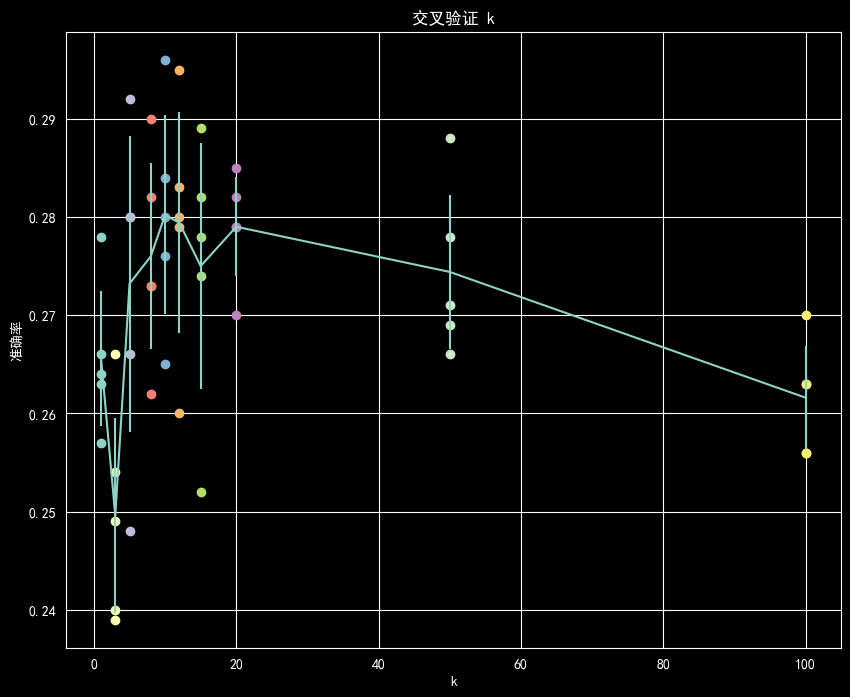

In [55]:
# 绘图显示
# 第一部分：绘制每个 k 的 5 折原始准确率散点图
for k in k_choices:
    accuracies = k_to_accuracies[k]  # 获取当前k的5个准确率
    plt.scatter([k] * len(accuracies), accuracies)  # 绘制散点 (x 轴：固定的k值（如5个1）, y 轴：5个不同的准确率)
# 第二部分：绘制带标准差误差棒的平均准确率趋势线
# 计算每个k的平均准确率，按k从小到大排序
accuracies_mean = np.array([np.mean(v) for k,v in sorted(k_to_accuracies.items())])  # .items()：取出字典的键值对
# 计算每个k的准确率标准差，按k从小到大排序
accuracies_std = np.array([np.std(v) for k,v in sorted(k_to_accuracies.items())])  # np.std(v)：计算每个k的准确率标准差（标准差越小，模型在不同数据上的表现越稳定）
# 绘制带误差棒的折线图 (效果：一条折线连接所有k的平均准确率，每个点上下有 “误差线”，误差线越长，说明该k的性能波动越大（越不稳定)
plt.errorbar(k_choices, accuracies_mean, yerr=accuracies_std)
'''
plt.errorbar：       Matplotlib 中绘制 “带误差棒” 折线图的专用函数
k_choices：          x 轴数据（所有候选k值，需和accuracies_mean顺序一致）
accuracies_mean：    y 轴主线数据（每个k的平均准确率）
yerr=accuracies_std：y 轴误差棒的长度（上下各延伸 1 个标准差）
'''
plt.title('交叉验证 k')
plt.xlabel('k')
plt.ylabel('准确率')
plt.show()

In [59]:
# 基于以上交叉验证，选择一个最好的k，用所有的训练数据重新训练，在测试集上测试，大约能得到28%的准确率
classifier = KNearestNeighbor()
classifier.train(X_train, y_train)
y_test_pred = classifier.predict(X_test, k=best_k)
# 计算、展示准确率
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print('有 %d / %d 正确 => 准确率: %f' % (num_correct, num_test, accuracy))

有 141 / 500 正确 => 准确率: 0.282000


KNN 核心特性总结
- 训练误差：1-NN 在训练集上每个样本自身为最近邻，训练误差为 0；但 k 值过小易过拟合，对噪声和离群点敏感，泛化能力弱。
- 决策边界：k-NN 的决策边界由训练样本分布决定，呈高度非线性，对应 Voronoi 多边形形态，并非线性边界。
- 推理复杂度：k-NN 为惰性学习算法，推理阶段需计算测试样本与全量训练样本的距离，推理耗时随训练数据量线性增长。
